Satellite Digital Twin - Model Evaluation

Accuracy : 17.14%

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.14      0.25      9329
           1       0.04      1.00      0.08       141
           2       0.40      0.46      0.43       118
           3       0.00      0.00      0.00       159
           4       0.07      1.00      0.13       135
           5       0.10      0.59      0.17        82
           6       0.00      0.22      0.01        36

    accuracy                           0.17     10000
   macro avg       0.23      0.49      0.15     10000
weighted avg       0.92      0.17      0.24     10000



c:\Users\hp\OneDrive\Documents\Satellite-Digital-Twin\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Documents\Satellite-Digital-Twin\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\OneDrive\Documents\Satellite-Digital-Twin\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


<Figure size 800x800 with 0 Axes>

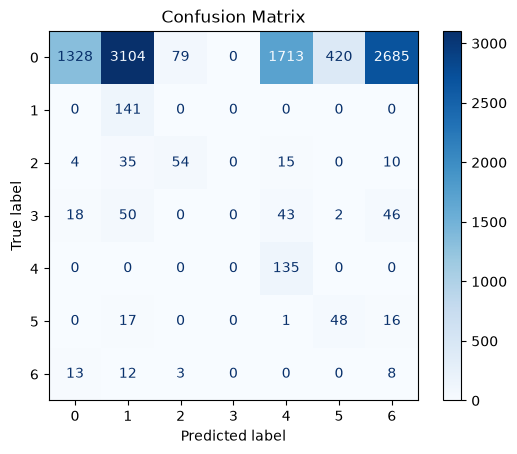

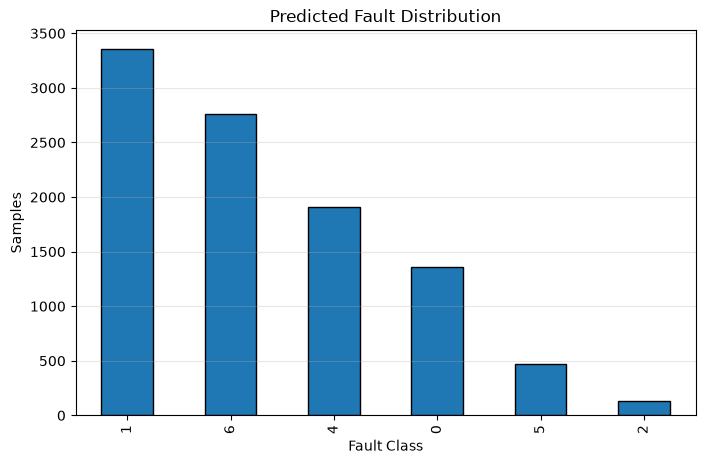

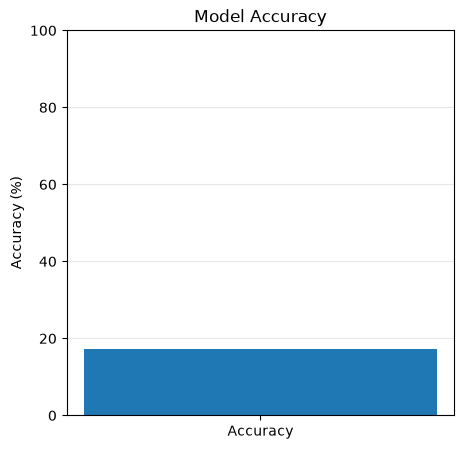


Prediction Samples


,Actual,Predicted
0,0,1
1,0,1
2,0,6
3,0,1
4,0,0
5,0,0
6,0,1
7,0,0
8,0,1
9,0,1



Notebook Completed Successfully.


In [1]:
# ==========================================================
# Satellite Digital Twin
# Notebook 05 - Model Evaluation
# ==========================================================

from pathlib import Path
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# Project Paths
# ----------------------------------------------------------

PROJECT_ROOT = Path("..").resolve()

DATASET_DIR = PROJECT_ROOT / "datasets"
MODEL_DIR = PROJECT_ROOT / "saved_models"

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

test_df = pd.read_csv(DATASET_DIR / "test_scaled.csv")

FEATURE_COLUMNS = [
    "OrbitPhase (%)",
    "Sunlight (0 or 1)",
    "BusVoltage (V)",
    "BusCurrent (A)",
    "BatteryVoltage (V)",
    "BatteryTemperature (°C)",
    "BatterySOC (%)",
    "SolarVoltage (V)",
    "SolarCurrent (A)",
    "WheelRPM (RPM)",
    "WheelTemperature (°C)",
    "CPUUsage (%)",
    "CPUTemperature (°C)",
    "SignalStrength (dBm)",
    "GyroMagnitude (deg/s)",
    "Altitude (km)"
]

TARGET_COLUMN = "FaultLabel"

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

# ----------------------------------------------------------
# Load Model
# ----------------------------------------------------------

model = joblib.load(MODEL_DIR / "xgboost.pkl")

# ----------------------------------------------------------
# Predict
# ----------------------------------------------------------

predictions = model.predict(X_test)

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

accuracy = accuracy_score(y_test, predictions)

print("=" * 70)
print("Satellite Digital Twin - Model Evaluation")
print("=" * 70)

print(f"\nAccuracy : {accuracy*100:.2f}%")

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("\nClassification Report\n")

print(classification_report(
    y_test,
    predictions
))

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_test.unique())
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix")

plt.show()

# ----------------------------------------------------------
# Prediction Distribution
# ----------------------------------------------------------

prediction_counts = pd.Series(predictions).value_counts()

plt.figure(figsize=(8,5))

prediction_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Predicted Fault Distribution")

plt.xlabel("Fault Class")

plt.ylabel("Samples")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# Accuracy Visualization
# ----------------------------------------------------------

plt.figure(figsize=(5,5))

plt.bar(
    ["Accuracy"],
    [accuracy * 100]
)

plt.ylim(0,100)

plt.ylabel("Accuracy (%)")

plt.title("Model Accuracy")

plt.grid(axis="y", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# Prediction Preview
# ----------------------------------------------------------

results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions

})

print("\nPrediction Samples")

display(results.head(25))

print("\nNotebook Completed Successfully.")